In [1]:
import pandas as pd
import joblib
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer

In [6]:
old_model = joblib.load("..\data\model.joblib")

C:\Users\loren\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\loren\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\loren\Ap

In [25]:
df = pd.read_csv("..\historical.csv")

binary_cats = ["gender","immunizations_done","reflexes_normal"]

#forward fill apgar_score by baby_id
#df['apgar_score'] = df.groupby('baby_id')['apgar_score'].ffill()

df = df.drop(columns= ["baby_id","name","date","birth_weight_kg","birth_length_cm","birth_head_circumference_cm","apgar_score"])


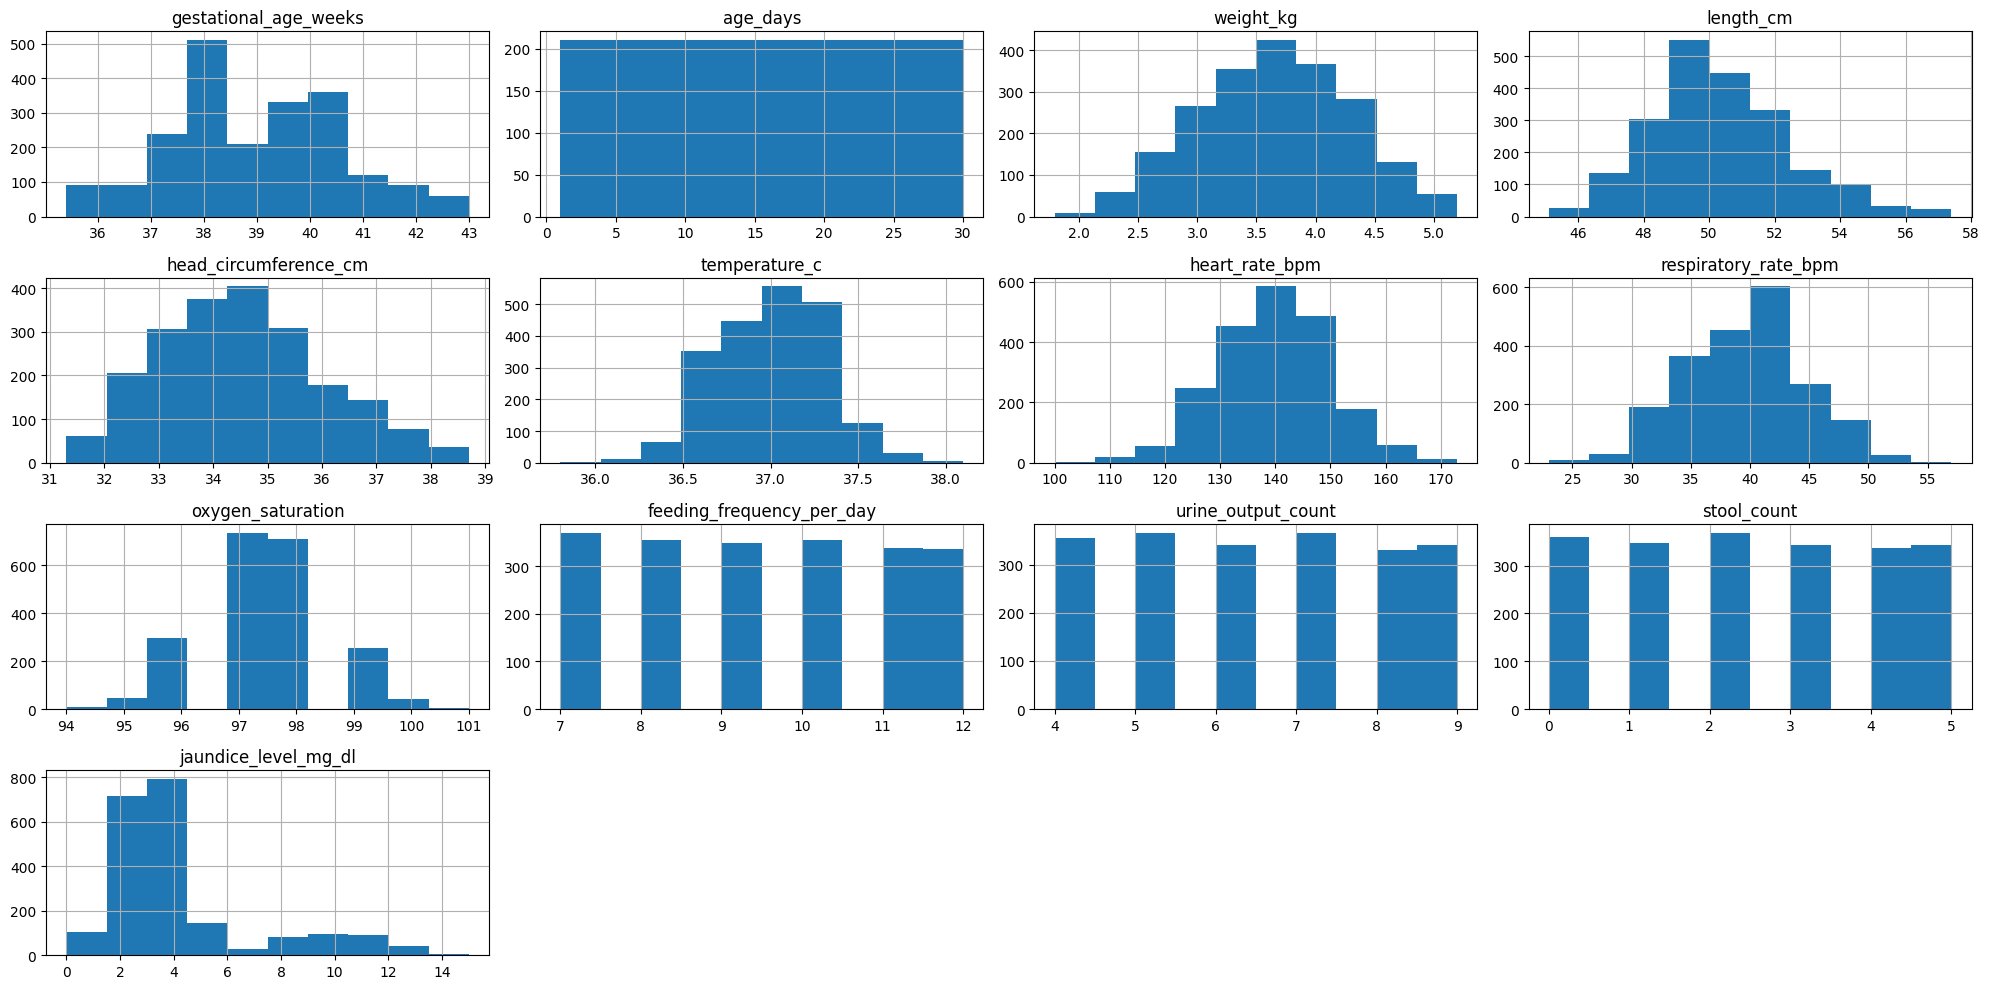

In [26]:
df.hist(figsize=(20, 10))
plt.tight_layout()

In [27]:
df.isnull().sum()

gender                       0
gestational_age_weeks        0
age_days                     0
weight_kg                    0
length_cm                    0
head_circumference_cm        0
temperature_c                0
heart_rate_bpm               0
respiratory_rate_bpm         0
oxygen_saturation            0
feeding_type                 0
feeding_frequency_per_day    0
urine_output_count           0
stool_count                  0
jaundice_level_mg_dl         0
immunizations_done           0
reflexes_normal              0
risk_level                   0
dtype: int64

In [28]:
df.head(30)



,gender,gestational_age_weeks,age_days,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,immunizations_done,reflexes_normal,risk_level
0,Female,40.2,1,3.28,50.1,32.0,37.0,160,36,98,Formula,11,9,0,4.2,Yes,Yes,At Risk
1,Female,40.2,2,3.35,50.2,32.0,37.2,156,40,99,Formula,11,5,2,10.6,No,No,At Risk
2,Female,40.2,3,3.35,50.6,32.1,37.1,137,37,97,Breastfeeding,7,6,5,9.8,No,No,Healthy
3,Female,40.2,4,3.48,50.3,32.0,37.4,130,33,97,Mixed,11,8,4,8.1,No,Yes,Healthy
4,Female,40.2,5,3.50,50.3,31.8,36.8,138,39,96,Breastfeeding,11,7,1,11.6,No,Yes,At Risk
5,Female,40.2,6,3.46,50.7,32.1,37.3,136,37,97,Mixed,10,6,0,10.1,No,Yes,At Risk
6,Female,40.2,7,3.53,50.9,32.0,37.0,147,36,98,Formula,11,8,1,4.0,No,No,Healthy
7,Female,40.2,8,3.57,50.3,32.1,36.7,133,40,98,Formula,7,7,2,2.1,No,Yes,Healthy
8,Female,40.2,9,3.51,50.5,32.1,37.4,135,35,97,Mixed,7,4,2,3.8,No,Yes,Healthy
9,Female,40.2,10,3.69,50.6,31.9,36.8,133,36,96,Mixed,7,8,2,2.7,No,No,Healthy


## Univariate Analysis

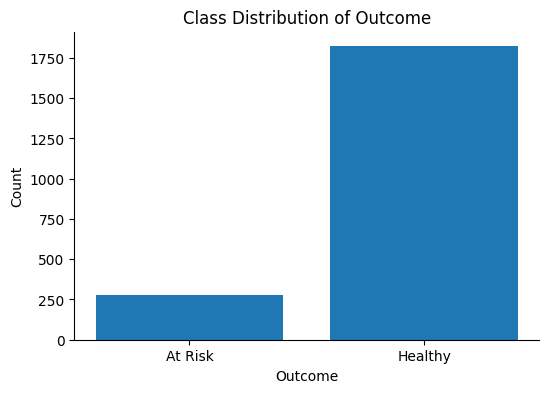

risk_level
At Risk     278
Healthy    1822
Name: count, dtype: int64


In [29]:
class_counts = df["risk_level"].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution of Outcome")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()
print(class_counts)


### We can see that theres a class imbalance so we'll have to account for that later

Now to convert the categorical variables to numerical

In [30]:
# Initialize the LabelBinarizer
lb = LabelBinarizer()
oh = OneHotEncoder()

# Loop through each specified column and binarize it
for col in binary_cats:
    df[col] = lb.fit_transform(df[[col]])

df['risk_level'] = np.where(df['risk_level'] == 'At Risk', 1, 0)


In [31]:
# Initialize the OneHotEncoder
oh = OneHotEncoder()

# Fit and transform the "feeding_type" column
feedingtype = oh.fit_transform(df[["feeding_type"]])
feedingtype_df = pd.DataFrame(feedingtype.toarray(), columns=oh.get_feature_names_out(["feeding_type"]))

# Concatenate the original DataFrame with the new encoded columns
df_clean = pd.concat([df.reset_index(drop=True), feedingtype_df], axis=1)
df_clean.drop("feeding_type", axis=1, inplace=True)


df_clean


,gender,gestational_age_weeks,age_days,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,immunizations_done,reflexes_normal,risk_level,feeding_type_Breastfeeding,feeding_type_Formula,feeding_type_Mixed
0,0,40.2,1,3.28,50.1,32.0,37.0,160,36,98,11,9,0,4.2,1,1,1,0.0,1.0,0.0
1,0,40.2,2,3.35,50.2,32.0,37.2,156,40,99,11,5,2,10.6,0,0,1,0.0,1.0,0.0
2,0,40.2,3,3.35,50.6,32.1,37.1,137,37,97,7,6,5,9.8,0,0,0,1.0,0.0,0.0
3,0,40.2,4,3.48,50.3,32.0,37.4,130,33,97,11,8,4,8.1,0,1,0,0.0,0.0,1.0
4,0,40.2,5,3.50,50.3,31.8,36.8,138,39,96,11,7,1,11.6,0,1,1,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,0,41.7,26,4.99,52.5,34.8,37.1,141,36,98,8,8,2,2.5,0,1,0,0.0,0.0,1.0
2096,0,41.7,27,5.04,52.6,34.6,36.8,138,34,98,7,8,4,3.3,0,1,0,0.0,0.0,1.0
2097,0,41.7,28,5.05,52.9,34.9,37.3,131,46,97,11,6,2,3.2,0,1,0,0.0,0.0,1.0
2098,0,41.7,29,5.03,52.9,34.8,37.0,133,45,98,10,5,5,3.2,0,1,0,0.0,0.0,1.0


## Bivariate Analysis 
### After that we can use a correlation matrix to see if anything interesting pops up

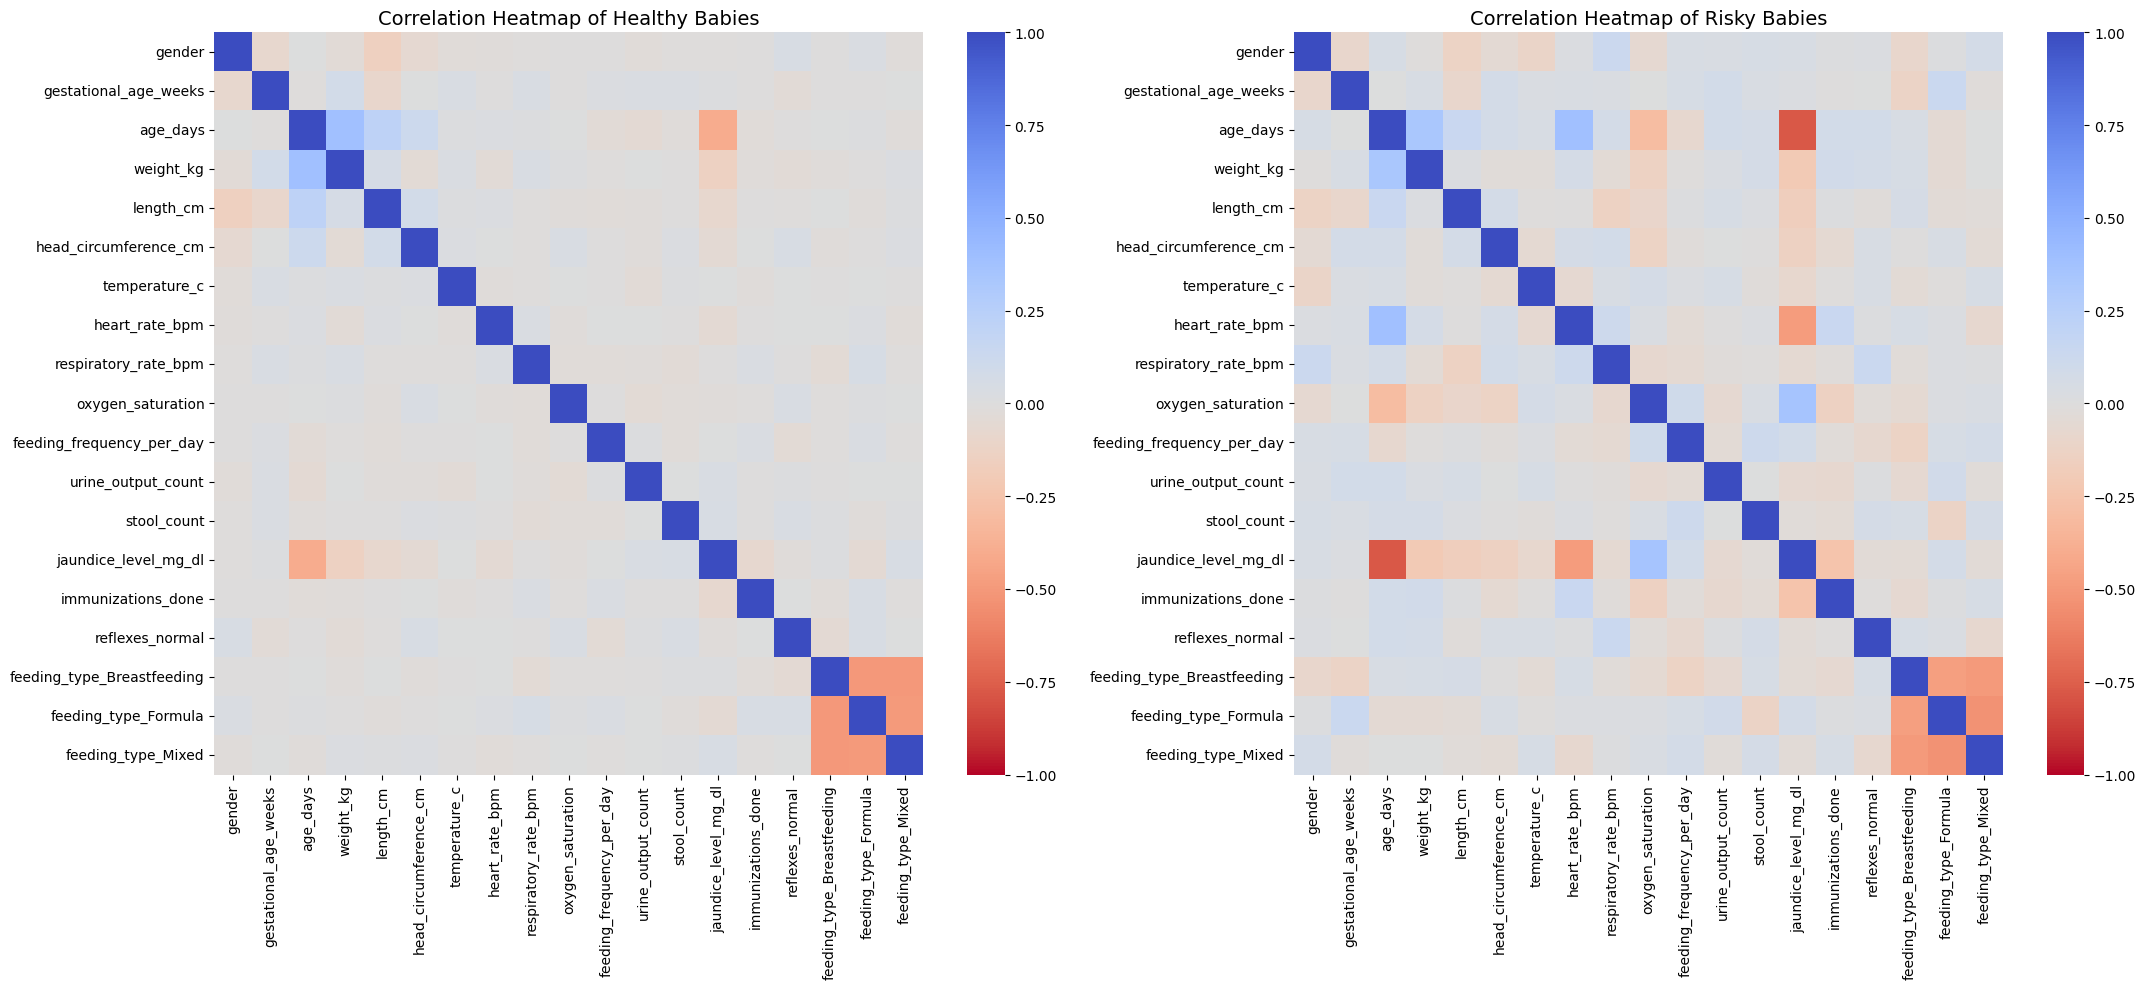

In [32]:
# Split datasets
is_fraud = df["risk_level"] == 1
is_healthy = df["risk_level"] == 0
df_0 = df_clean[is_healthy]
df_1 = df_clean[is_fraud]

corr_0 = df_0.drop(df_0.columns[-4], axis=1).corr()
corr_1 = df_1.drop(df_1.columns[-4], axis=1).corr()

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(
    corr_0,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[0]
)
axes[0].set_title("Correlation Heatmap of Healthy Babies", fontsize=14)

sns.heatmap(
    corr_1,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("Correlation Heatmap of Risky Babies", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
#sns.pairplot(data= df,hue="risk_level")

<Axes: xlabel='age_days', ylabel='jaundice_level_mg_dl'>

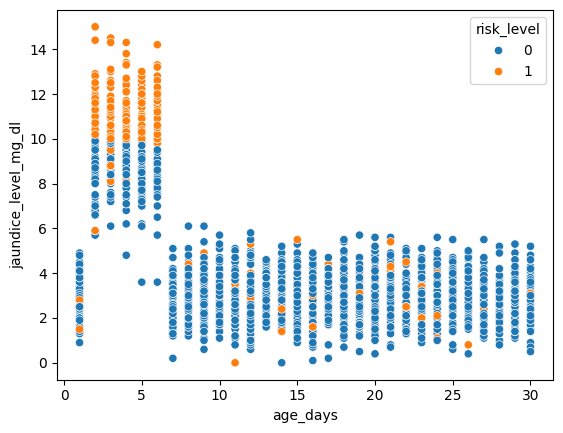

In [ ]:
sns.scatterplot(data= df,x="age_days",y="jaundice_level_mg_dl", hue = "risk_level")

<Axes: xlabel='jaundice_level_mg_dl', ylabel='heart_rate_bpm'>

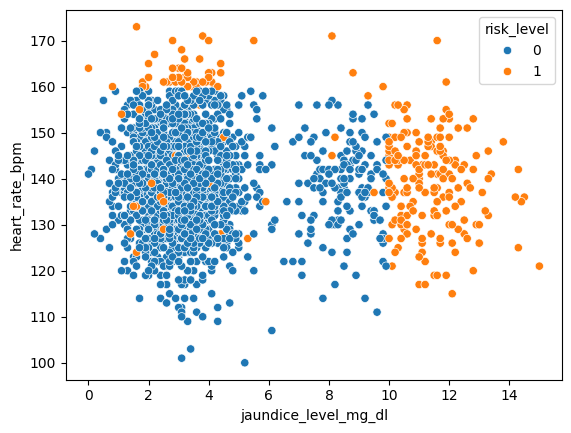

In [ ]:
sns.scatterplot(data= df,x="jaundice_level_mg_dl",y="heart_rate_bpm", hue = "risk_level")

<Axes: xlabel='age_days', ylabel='oxygen_saturation'>

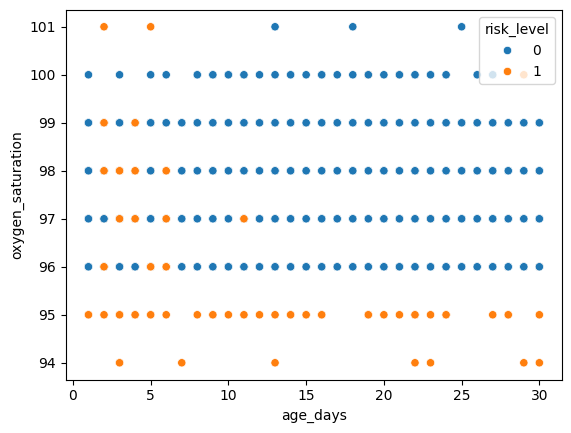

In [ ]:
sns.scatterplot(data= df,x="age_days",y="oxygen_saturation", hue = "risk_level")